In [1]:
import os
import re
import h5py
import random

import nibabel as nib
import numpy as np
import colorcet as cc
import networkx as nx
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.io as sio

from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from h5py import File
from pathlib import Path
from tqdm import tqdm
from scipy import ndimage

from matplotlib.colorbar import ColorbarBase
from scipy.stats import wilcoxon, mannwhitneyu
from matplotlib.patches import ArrowStyle, FancyArrowPatch
from matplotlib.colors import ListedColormap
from nilearn.masking import apply_mask, unmask
from nilearn.image import concat_imgs

/media/DATA/jmariani/4_utils/miniconda3/envs/JCmri/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
def mat_2_vect(transition_matrix):

    nb_caps = transition_matrix.shape[0]

    inds = np.tril(np.ones((nb_caps, nb_caps))).reshape(nb_caps*nb_caps).astype(bool)

    return transition_matrix.reshape(nb_caps*nb_caps)[inds]

def vect_2_mat(transition_vect, nb_caps):

    output_vect = np.zeros(nb_caps*nb_caps)

    inds = np.where(np.tril(np.ones((nb_caps, nb_caps))).reshape(nb_caps*nb_caps).astype(bool))

    output_vect[inds] = transition_vect

    output_mat = output_vect.reshape((nb_caps, nb_caps))

    a = np.rot90(np.flip(output_mat.copy(), 1))
    
    for i in range(nb_caps):
        a[i,i] = 0
        t_mat = output_mat + a

    return t_mat

def apply_new_order(vect, new_order):
    
    return np.array([new_order[int(x)-1] for x in vect])


def compute_transition_matrix(vect, nb_caps = 8):
    
    count_matrix = np.zeros((nb_caps, nb_caps))

    for x,y in zip(vect[:-1].astype(int), vect[1:].astype(int)):

        count_matrix[x-1,y-1] = count_matrix[x-1,y-1] + 1

    for i in range(nb_caps):
        count_matrix[i,i] = 0

    transition_matrix = count_matrix.copy()

    transition_matrix = transition_matrix/transition_matrix.sum()
    
    return transition_matrix

def delta_theta(ref_theta, delta_theta, r = 0.1):

    return (
        r*np.cos(ref_theta+delta_theta/2),
        r*np.sin(ref_theta+delta_theta/2),
        r*np.cos(ref_theta-delta_theta/2),
        r*np.sin(ref_theta-delta_theta/2),
    )
    
def display_transition_matrix(
    transition_mat,
    edge_threshold = 0.04,
    edge_width_factor = 50,
    cmap_net = cc.cm['CET_L17'],
    figsize = [5,5],
    dpi = 200
):

    fig, ax = plt.subplots(1,1,figsize = figsize, dpi = dpi)
    
    nb_caps = transition_mat.shape[0]
    
    # @title Plotting transition network
    
    cmap = cc.cm['CET_D1']
    cmap0 = cmap([0.7,0.3])
    cmap1 = cmap([0.,1.])
    
    
    matrix = transition_mat.copy()
    
    for i in range(nb_caps):
        matrix[i,i] = 0
    
    G = nx.DiGraph(incoming_graph_data=matrix)
    pos = nx.circular_layout(G)
    
    if G.number_of_edges() > 0:
        edges, weights = zip(
            *[
                x
                for x in nx.get_edge_attributes(G, "weight").items()
                if abs(x[1]) >= edge_threshold
            ]
        )
    else:
        edges = []
        weights = 0
    
    edge_colors = []    
    for edge, weight in zip(edges, weights):
        # edge_colors.append(cc.cm['CET_L17'](int(255*(weight-edge_threshold)/(max(weights)-edge_threshold))))
        edge_colors.append(cmap_net(int(255*(weight)/(max(weights)))))
    
    isort = np.argsort(weights).astype(int)
    
    
    nx.draw_circular(
        G,
        ax = ax,
        edgelist=np.array(edges)[isort],
        connectionstyle='arc3,rad=0.2',
        width=((np.abs(weights)-edge_threshold) * edge_width_factor)[isort] + 0.1,
        min_source_margin = 20,
        min_target_margin = 20,
        labels = {x:str(x+1) for x in np.arange(nb_caps)},
        node_color = [cmap0[i%2] for i in range(nb_caps)],
        arrowstyle = ArrowStyle.Wedge(tail_width=0.8, shrink_factor=0.5),
        edge_color = np.array(edge_colors)[isort]
    )
    
    # For self transition
    
    for i in range(transition_mat.shape[0]):
    
        edge_val = transition_mat[i,i]
        
        if abs(edge_val) > edge_threshold:
            
            delta_pos = delta_theta(
                [-1*np.pi/3, 2*np.pi/3, np.pi/3, 4*np.pi/3, np.pi, 0][i],
                delta_theta = np.pi/3,
                r = 0.2
            )
            
            loop = FancyArrowPatch(
                posA=[pos[i][0]+delta_pos[0], pos[i][1]+delta_pos[1]],
                posB=[pos[i][0]+delta_pos[2], pos[i][1]+delta_pos[3]],
                connectionstyle="arc3,rad=-3",
                arrowstyle = ArrowStyle.Wedge(tail_width=0.8, shrink_factor=0.5),
                color=cmap_net(int(255*(edge_val)/(max(weights)))),
                linewidth = ((edge_val-edge_threshold)*edge_width_factor + 0.1),
                mutation_scale=10,
                linestyle = 'solid'
            )
    
            ax.add_patch(loop)
    
    # Add to the axes
    # ax.add_patch(arrow)
    
    _ = plt.axis('equal')

    return fig, ax

from scipy.stats import shapiro, bartlett, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def apply_FDR(p_vals, fdr_alpha = 0.05):

    return multipletests(
            p_vals,
            method = "fdr_bh",
            alpha = fdr_alpha
        )[1]

def compute_lvl2(group1, group2, edge_threshold, flag_correct = True):

    nb_caps = group1[0].shape[0]
    
    inds = (np.diag(np.ones(nb_caps)) == 0).reshape(nb_caps*nb_caps)
    
    cms_vect = np.array([x.reshape((nb_caps*nb_caps))[inds] for x in group1])

    cms_ref_vect = np.array([x.reshape((nb_caps*nb_caps))[inds] for x in group2])

    pvals = []

    for x,y in zip(cms_vect.T, cms_ref_vect.T):

        pvals.append(mannwhitneyu(x, y, alternative="two-sided", nan_policy = "omit").pvalue)

    if flag_correct:
        a = apply_FDR(pvals)
        output = np.zeros((nb_caps*nb_caps))
        output[inds] = a
    else:
        output = np.zeros((nb_caps*nb_caps))
        output[inds] = np.array(pvals)
        
    signif = output.reshape((nb_caps, nb_caps))< edge_threshold
    
    pvals_mat = output.reshape(nb_caps, nb_caps)

    with np.errstate(divide = 'ignore', invalid = 'ignore'):

        effect = np.nanmean(group2,0)
        effect_diff = np.nanmean(group2,0)-np.nanmean(group1,0)

    return signif, effect, effect_diff, pvals_mat


def compute_lvl2_onesample(group1, edge_threshold, flag_correct = True):

    nb_caps = group1[0].shape[0]
    
    inds = (np.diag(np.ones(nb_caps)) == 0).reshape(nb_caps*nb_caps)
    
    cms_vect = np.array([x.reshape((nb_caps*nb_caps))[inds] for x in group1])
    
    cms_null = np.median(cms_vect)*np.ones(cms_vect.shape[0])

    pvals = []

    for x in (cms_vect.T):

        if (x == 0).sum() == len(x):
            pvals.append(1.)
        else:
            pvals.append(wilcoxon(x, cms_null, alternative="two-sided", nan_policy = "omit").pvalue)

    if flag_correct:
        a = apply_FDR(pvals)
        output = np.zeros((nb_caps*nb_caps))
        output[inds] = a
    else:
        output = np.zeros((nb_caps*nb_caps))
        output[inds] = np.array(pvals)
        
    signif = output.reshape((nb_caps, nb_caps))< edge_threshold
    
    pvals_mat = output.reshape(nb_caps, nb_caps)

    with np.errstate(divide = 'ignore', invalid = 'ignore'):

        effect = np.nanmean(group1,0)
        effect_diff = np.nanmean(group1,0)-(np.median(cms_vect)*np.ones(effect.shape))

    return signif, effect, effect_diff, pvals_mat


def display_transition_matrix_stat(
    signif,
    effect_diff,
    edge_threshold = 0.04,
    edge_width_factor = 50,
    color_styles = ['#b5383a', '#0269a1']
):

    nb_caps = effect_diff.shape[0]

    cmap = cc.cm['CET_D1']
    cmap0 = cmap([0.3,0.7])
    cmap1 = cmap([0.,1.])


    matrix = signif.copy()
    for i in range(nb_caps):
        matrix[i,i] = 0


    G = nx.DiGraph(incoming_graph_data=matrix)
    pos = nx.circular_layout(G)

    if G.number_of_edges() > 0:
        edges, weights, colors = zip(
            *[
                [x[0], effect_diff[int(x[0][0]), int(x[0][1])], color_styles[effect_diff[int(x[0][0]), int(x[0][1])] > 0]]
                for x in nx.get_edge_attributes(G, "weight").items()
                if x[1] != 0
            ]
        )
    else:
        edges = []
        weights = 0
        lss = 'w'
        colors = []

    nx.draw_circular(
        G,
        edgelist=edges,
        connectionstyle='arc3,rad=0.2',
        width= np.abs(weights) * edge_width_factor,
        min_source_margin = 20,
        min_target_margin = 20,
        labels = {x:str(x+1) for x in np.arange(nb_caps)},
        node_color = [cmap0[i%2] for i in range(nb_caps)],
        edge_color = list(colors),
        arrowstyle = '-'
    )

    # For self transition
    
    for i in range(transition_mat.shape[0]):
    
        edge_val = transition_mat[i,i]
        
        if abs(edge_val) > edge_threshold:
            
            delta_pos = delta_theta(
                [-1*np.pi/3, 2*np.pi/3, np.pi/3, 4*np.pi/3, np.pi, 0][i],
                delta_theta = np.pi/3,
                r = 0.2
            )
            
            loop = FancyArrowPatch(
                posA=[pos[i][0]+delta_pos[0], pos[i][1]+delta_pos[1]],
                posB=[pos[i][0]+delta_pos[2], pos[i][1]+delta_pos[3]],
                connectionstyle="arc3,rad=-3",
                arrowstyle = ArrowStyle.Wedge(tail_width=0.8, shrink_factor=0.5),
                color=cmap_net(int(255*(edge_val)/(max(weights)))),
                linewidth = ((edge_val-edge_threshold)*edge_width_factor + 0.1),
                mutation_scale=10
            )
    
            ax.add_patch(loop)

    _ = plt.axis('equal')

    return

def display_cap_stat(cap_occ, cap_id):
    
    for i,x in enumerate(cap_occ):
        
        plt.bar(i,x[:,cap_id].mean(),color=mcolors.to_rgb(f'C{i}')+(0.25,))
        plt.scatter(i*np.ones(len(x)),x[:,cap_id],c=mcolors.to_rgb(f'C{i}')+(0.5,))
        
    plt.xticks(range(len(cap_occ)), ds_name, c='w', fontsize = 7)
    plt.ylabel('CAP occurence', c='w', fontsize = 7)
    plt.ylim([0,0.3])
        
    return


def display_cap_bar(cap_occ, ylim = 0.3, alpha = 0.25, cmap = None):
    
    if cmap is not None:
        
        cmap0 = cmap([0.2,.8])

        for i,x in enumerate(cap_occ):

            if x == 0:
                
                plt.scatter(i,ylim/2,200,color=tuple(cmap0[i%2][:3])+(alpha,))
                
            else:
            
                plt.bar(i,x,color= tuple(cmap0[i%2][:3])+(alpha,))
    
    else:

        for i,x in enumerate(cap_occ):

            plt.bar(i,x,color=mcolors.to_rgb(f'C{i}')+(alpha,))
                
    plt.xticks(range(len(cap_occ)), [f'CAP-{j+1}' for j in range(nb_caps)], c='w', fontsize = 7)
    plt.ylabel('CAP transition probability', c='w', fontsize = 7)
    plt.ylim([0,ylim])
        
    return

# General parameters

In [3]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ CAPs parameter

# To be edited

analysis_name = 'CPT'
analysis_tag = 'k6'

#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ display parameters

################ Output data structure

output_root = Path('/media/DATA/jmariani/2_Results/2026-05-07_PepeMariani/Main-figure_05')
output_root.mkdir(exist_ok = True, parents = True)

## Colorbar

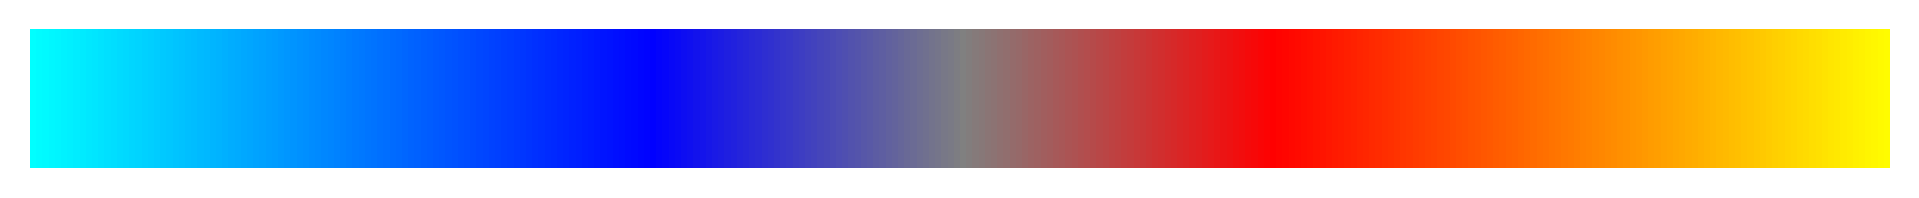

In [4]:
cmap_name = '../libraries/colourmaps/render3.cmap'

with open(cmap_name, 'r') as f:
    
    lines = f.readlines()
    
cmap_list = [[float(y) for y in x.split('\n')[0].split(' ')] for x in lines]

mymap = mcolors.ListedColormap(cmap_list)

fig, ax = plt.subplots(figsize=(8, 0.6), dpi=300)
cb = ColorbarBase(ax, cmap=mymap, orientation='horizontal')
cb.set_ticks([])
cb.outline.set_visible(False)
ax.set_axis_off()
fig.patch.set_alpha(0)

save_path = output_root / f'colorbar.svg'

plt.savefig(save_path, format="svg", transparent=True, bbox_inches="tight", pad_inches=0)

# Loads

In [5]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ CAPs parameters

nb_caps = int(analysis_tag.split('k')[1])
print(f'nb of CAPS: {nb_caps}')

root_name = Path('/media/DATA/jmariani/1_data/2026-04-13_PepeMariani/2026-02-03_PepeMariani_fUSI-anaesthetised/derivatives/analysis/CAPs/00_results')

cap_dyn_name = f'{root_name}/fus-caps_parcel_CPT_plus_analysis/cap_maps_lowres_{analysis_tag}/caps_dynamics_paper_{analysis_tag}_thr1_01-03hz/caps_dyn.mat'
cap_res_name = f'{root_name}/fus-caps_parcel_CPT_plus_analysis/cap_maps_lowres_{analysis_tag}/cap_results_{analysis_tag}.mat'
cap_mask_name = f'{root_name}/mask_info_{analysis_name}.mat'

# From dynamics

try:
    a = sio.loadmat(cap_dyn_name, struct_as_record=False)
    cap_ord = a['caps_dyn'][0,0].cap_ord[0]  
    ds_name = [x[0] for x in a['caps_dyn'][0,0].ds_name[0]]
    cap_occ = a['caps_dyn'][0,0].cap_occ[0] 
    print(f'dyn : Okay\nNew order: {" ".join([str(x) for x in cap_ord])}')
except:
    print('Didn''t find dyn')
    
# gets the cap new order (paired caps)
    
new_order = [np.where(cap_ord == i)[0][0]+1 for i in range(1, nb_caps+1)]

# extracts subject from MATLAB metadata

sub_list_name = root_name / Path(f'subject_list_CPT.mat')

indexes = []

with h5py.File(cap_res_name, 'r') as f:
    
    for x in f['results_map']['frame_ind_sub'] :
        
        indexes.append(apply_new_order(f[x[0]][:][0,:], new_order))
        
# Getting indexes of cohorts subject

cohort_lens = []
cohort_starts = []
count = 0

with h5py.File(sub_list_name,'r') as f:

    for x in f['sub_list']:

        cohort_lens.append(f[x[0]].shape[1])
        cohort_starts.append(count)
        count = count + f[x[0]].shape[1]
        
cohort_starts.append(len(indexes))

cohort_wise_indexes = {}
subject_wise_indexes = {x:[] for x in ds_name}

for i,(start, end) in enumerate(zip(cohort_starts[:-1], cohort_starts[1:])):
    
    cohort_wise_indexes[ds_name[i]] = np.zeros((0))
    
    for j in range(start, end):
        
        cohort_wise_indexes[ds_name[i]] = np.concatenate(
            (cohort_wise_indexes[ds_name[i]], indexes[j]),
            0
        )
        
        subject_wise_indexes[ds_name[i]].append(indexes[j])

nb of CAPS: 6
dyn : Okay
New order: 4 5 1 3 6 2


# Sample statistics

Concatenates all subject and estimate sample satistics.

## First Order

Computes first order transition probability matrix.

### Parameters

In [6]:
save_dir = output_root / f'Sample-statistics/First-order'
save_dir.mkdir(exist_ok = True, parents = True)

In [7]:
# Computes the transition matrices cohort wise

save_folder = save_dir / 'cohort_wise'
save_folder.mkdir(parents = True, exist_ok = True)

transition_matrices = {}

for cohort_id, cohort_name in enumerate(ds_name):

    count_matrix = np.zeros((nb_caps, nb_caps))

    for x,y in zip(cohort_wise_indexes[ds_name[cohort_id]][:-1].astype(int), cohort_wise_indexes[ds_name[cohort_id]][1:].astype(int)):

        count_matrix[x-1,y-1] = count_matrix[x-1,y-1] + 1

    for i in range(nb_caps):
        count_matrix[i,i] = 0

    transition_matrix = count_matrix.copy()

    transition_matrix = transition_matrix/transition_matrix.sum()
    
    transition_matrices[cohort_name] = transition_matrix

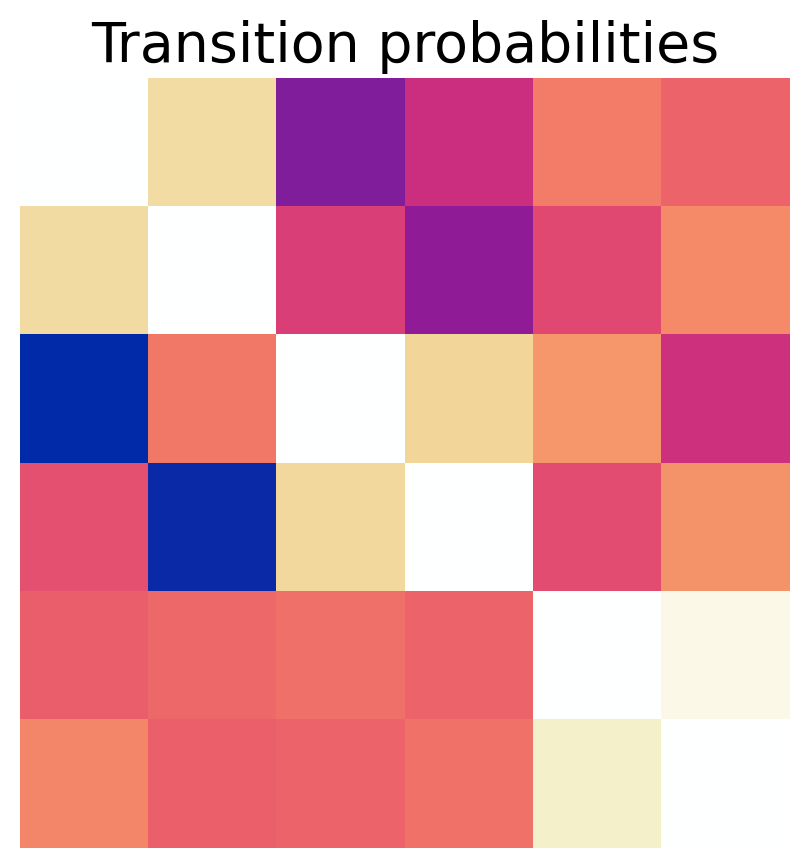

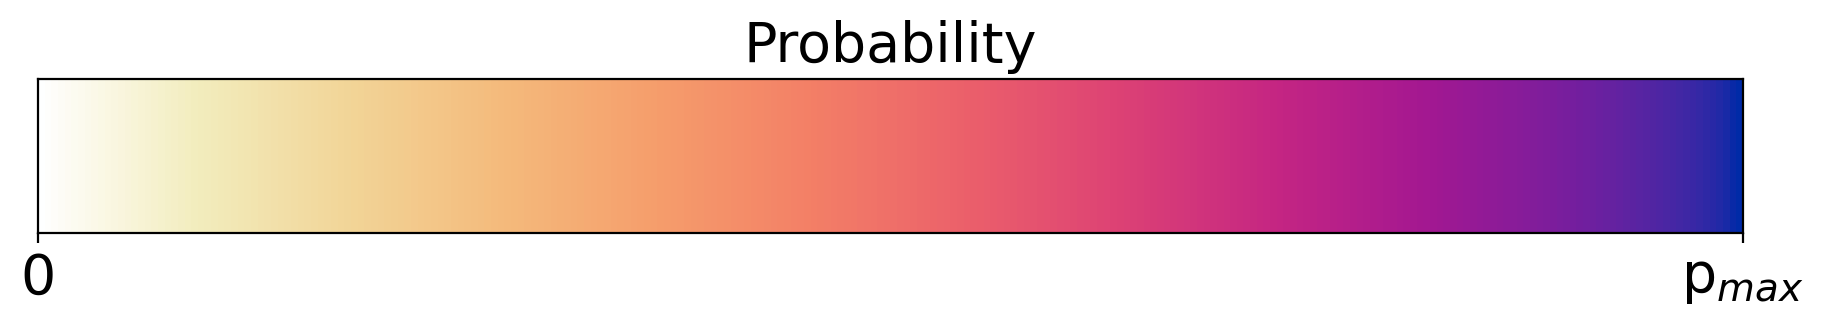

In [8]:
# displays transition probability matrix and associated colorbar

colormap_tag = 'CET_L17'

cmap = cc.cm[colormap_tag]

plt.figure(figsize = (5,5), dpi = 200)

plt.imshow(transition_matrices[cohort_name], cmap = cmap)
plt.axis('off')

plt.title('Transition probabilities', fontsize = 20)

v = np.linspace(0,1, 256)

save_name = save_dir / f'00_single-step_transition_matrix_{colormap_tag}.png'
save_name.parent.mkdir(exist_ok = True, parents = True)
plt.savefig(save_name)
save_name = save_dir / f'00_single-step_transition_matrix_{colormap_tag}.svg'
plt.savefig(save_name)

###################### Colorbar

plt.figure(figsize = (11, 1), dpi = 200)

plt.imshow(v[:,None].T, cmap = cmap, aspect = 'auto')

plt.xticks([-0.5,255.5], ['0', 'p$_{max}$'], fontsize = 20)
plt.yticks([])

plt.title('Probability', fontsize = 20)

save_name = save_dir / f'00_single-step_transition_matrix_colorbar_{colormap_tag}.png'
plt.savefig(save_name)
save_name = save_dir / f'00_single-step_transition_matrix_colorbar_{colormap_tag}.svg'
plt.savefig(save_name)

In [9]:
# Gets the display threshold based on control cohort

cohort_id = 0

maxs = []

for x, y in zip(transition_matrices[ds_name[cohort_id]], transition_matrices[ds_name[cohort_id]].T):
    
    maxs.append(min(max(x), max(y)))


# th = np.floor(maxs[np.argmin(maxs)]*1000)/1000
th = maxs[np.argmin(maxs)]
    
print(f'{np.argmin(maxs)} - {maxs[np.argmin(maxs)]} - th =  {th}')

5 - 0.035967375317555825 - th =  0.035967375317555825


### Network of transitions

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 1000x1000 with 0 Axes>

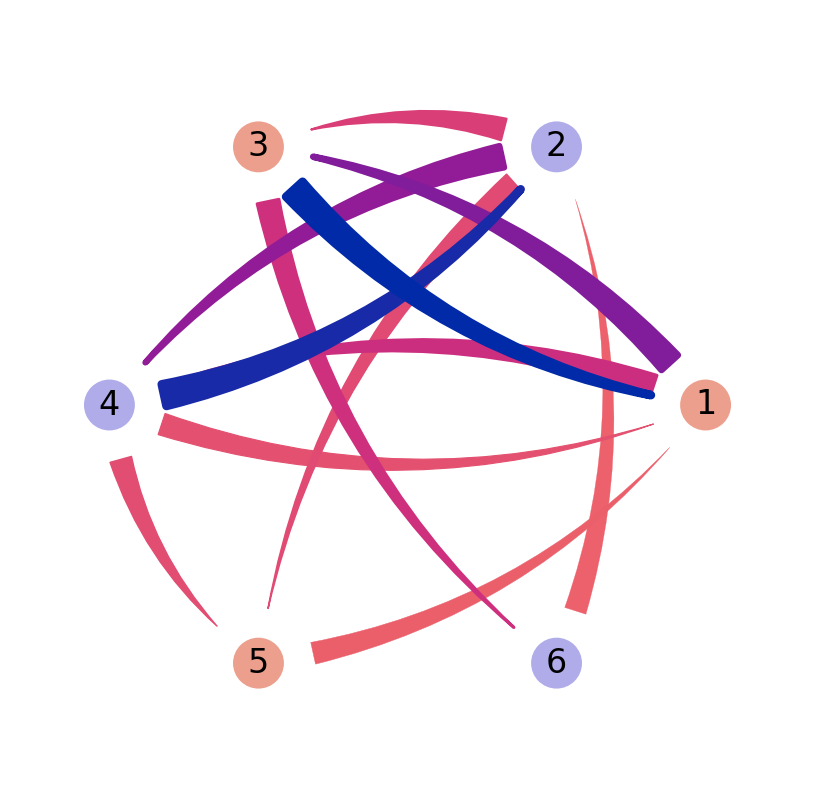

In [10]:
# displays networks

for cohort_name in ds_name:

    plt.figure(figsize = (5,5), dpi = 200)
    display_transition_matrix(transition_matrices[cohort_name], edge_threshold = th, edge_width_factor = 100, cmap_net = cmap)
    
    plt.axis([-1.3, 1.3, -1.3, 1.3])
    

    save_name = save_dir / f'01_single-step_transition_network_{colormap_tag}.png'
    plt.savefig(save_name)
    save_name = save_dir / f'01_single-step_transition_network_{colormap_tag}.svg'
    plt.savefig(save_name)
    

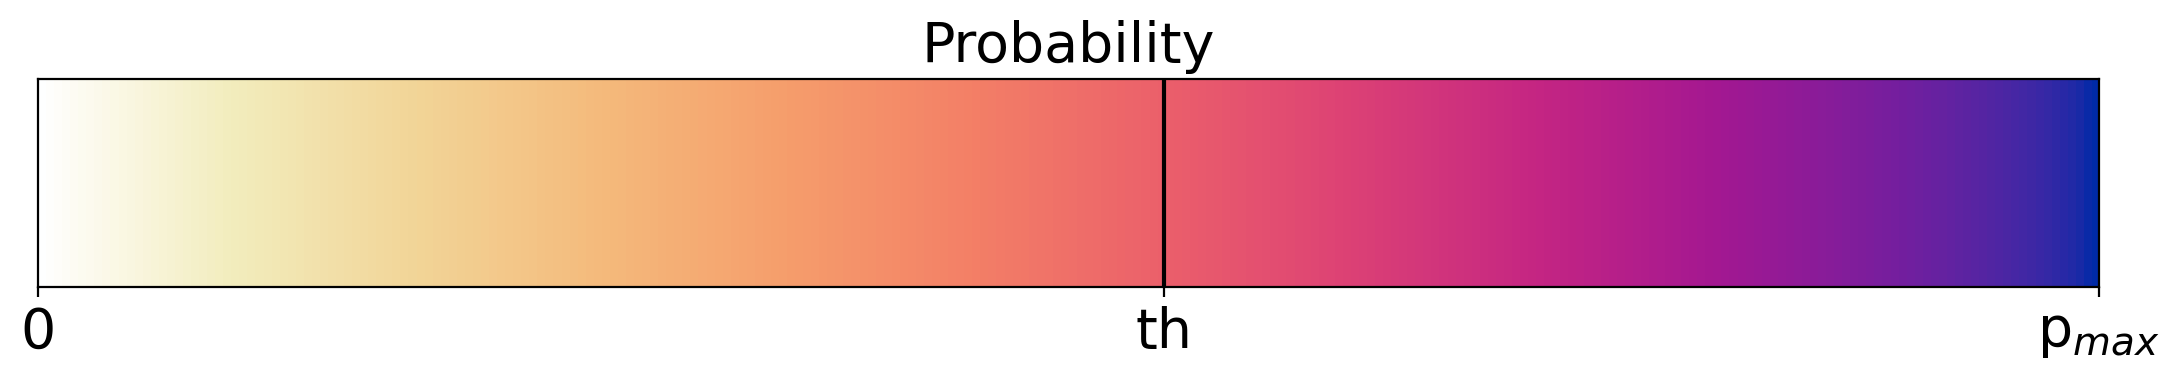

In [11]:
###################### Colorbar

plt.figure(figsize=(11, 2), dpi=200)

L = len(v)
cM = transition_matrices[cohort_name].max()
cm = transition_matrices[cohort_name].min()

# Plot colorbar
plt.imshow(v[:, None].T, cmap=cmap, aspect='auto')

# Compute threshold x-position in pixel coordinates
x_th = th * L / (cM - cm)

# Ticks
plt.xticks(
    [-0.5, x_th, 255.5],
    ['0', 'th', 'p$_{max}$'],
    fontsize=20
)
plt.yticks([])

# Threshold line
plt.axvline(x_th, color='k')

# Title
plt.title('Probability', fontsize=20)

plt.tight_layout()

# SAVE SVG
save_name = save_dir / f"00_single-step_transition_matrix_colorbar_with_threshold.svg"
plt.savefig(save_name, bbox_inches='tight', pad_inches=0)

plt.show()


### CAPs transition probabilities

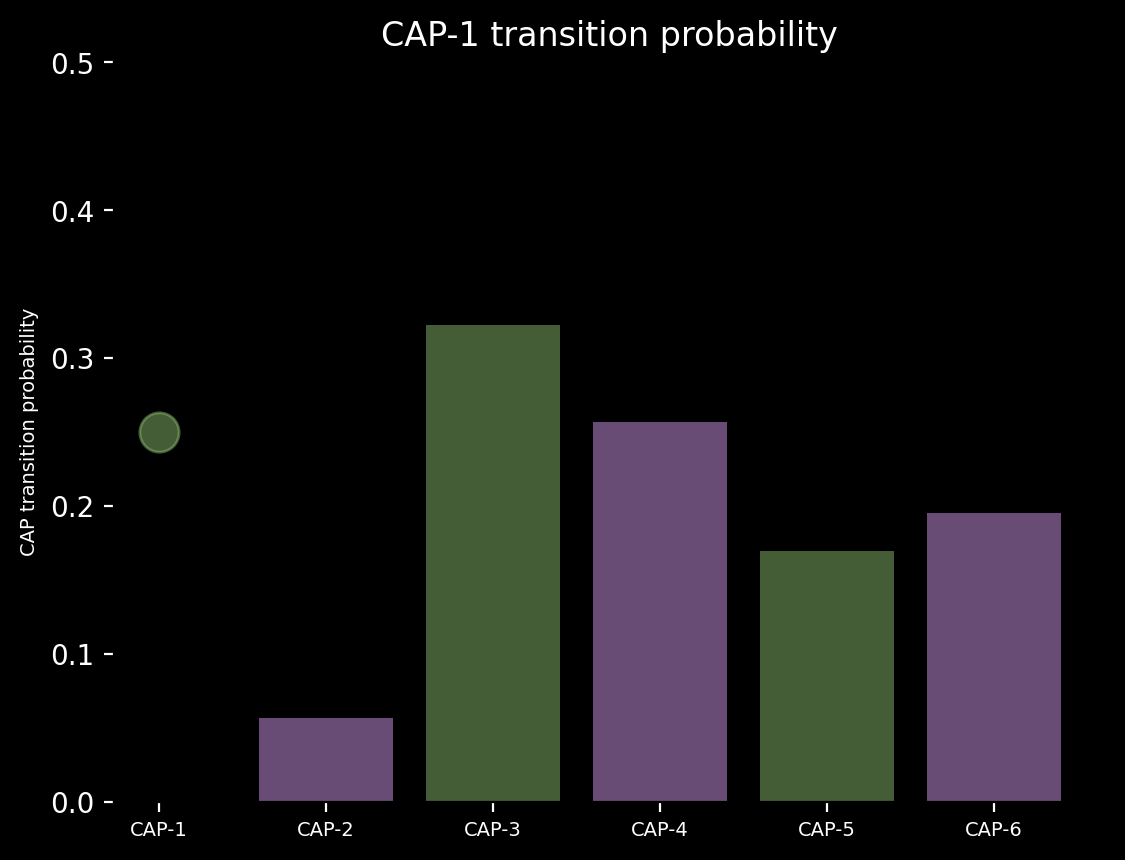

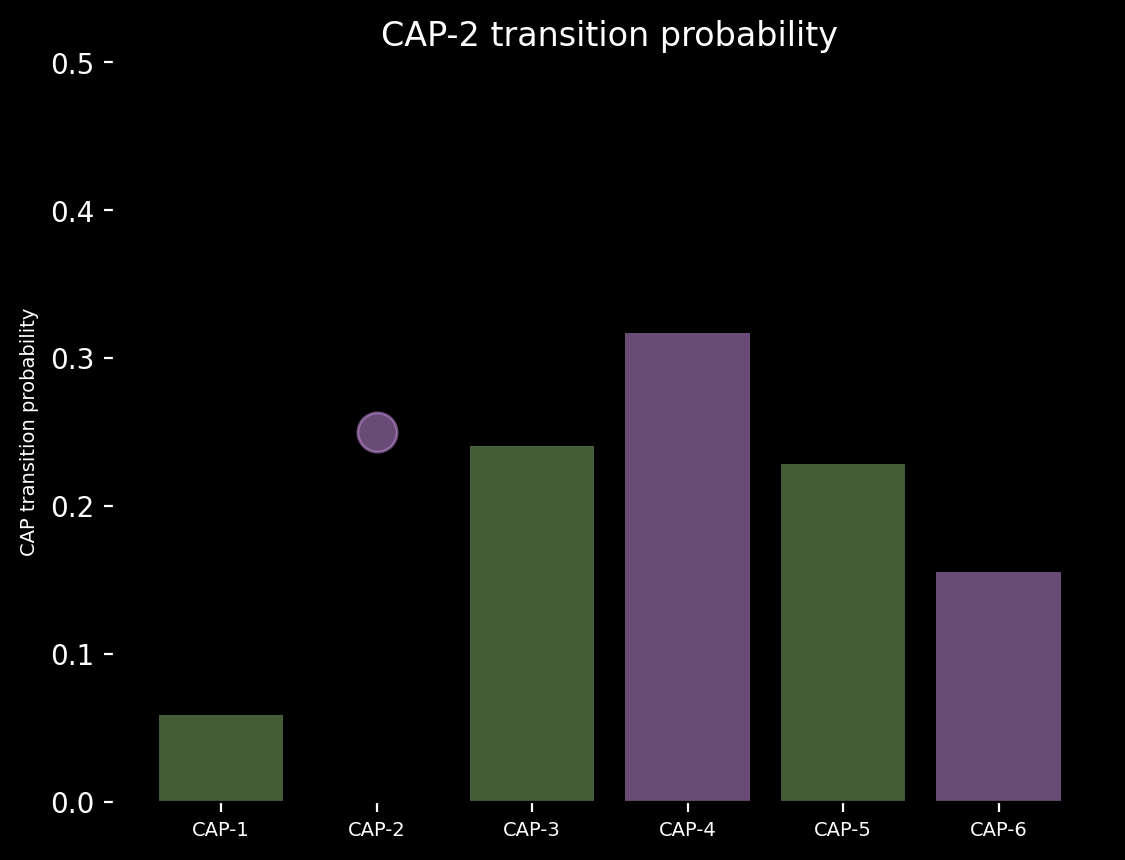

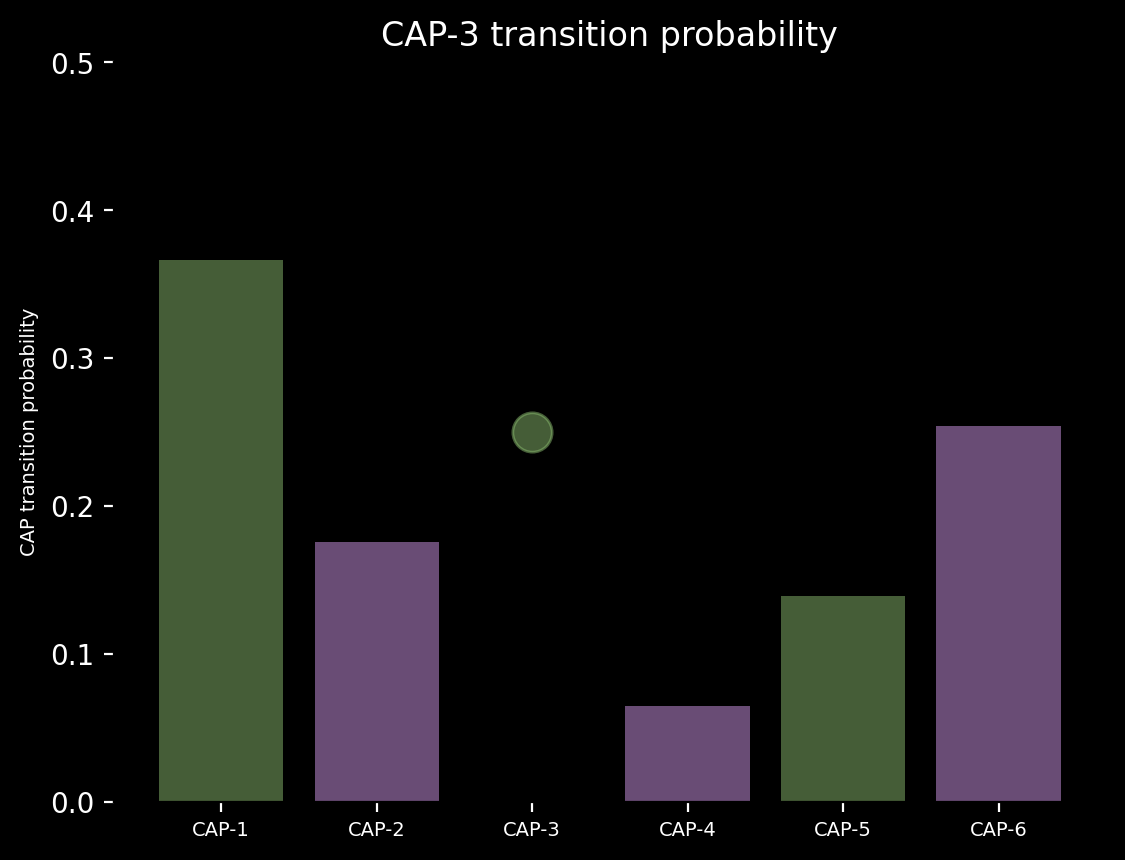

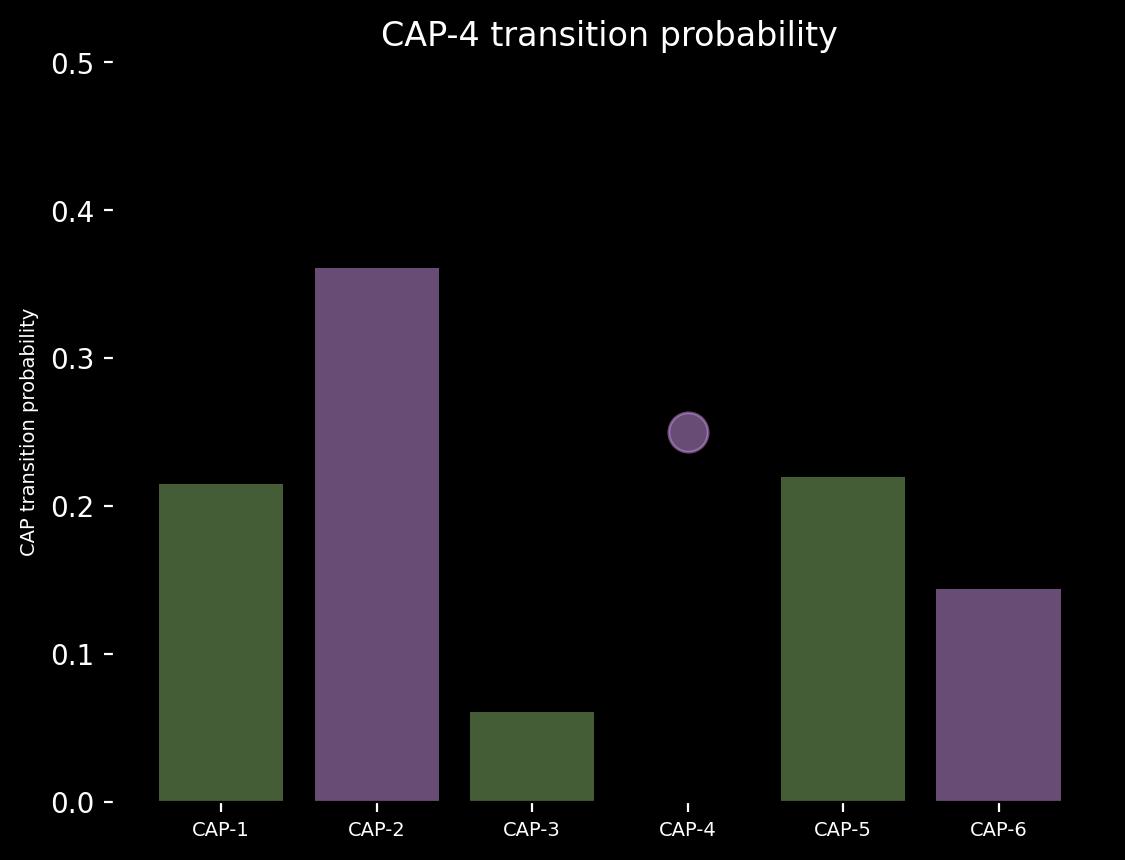

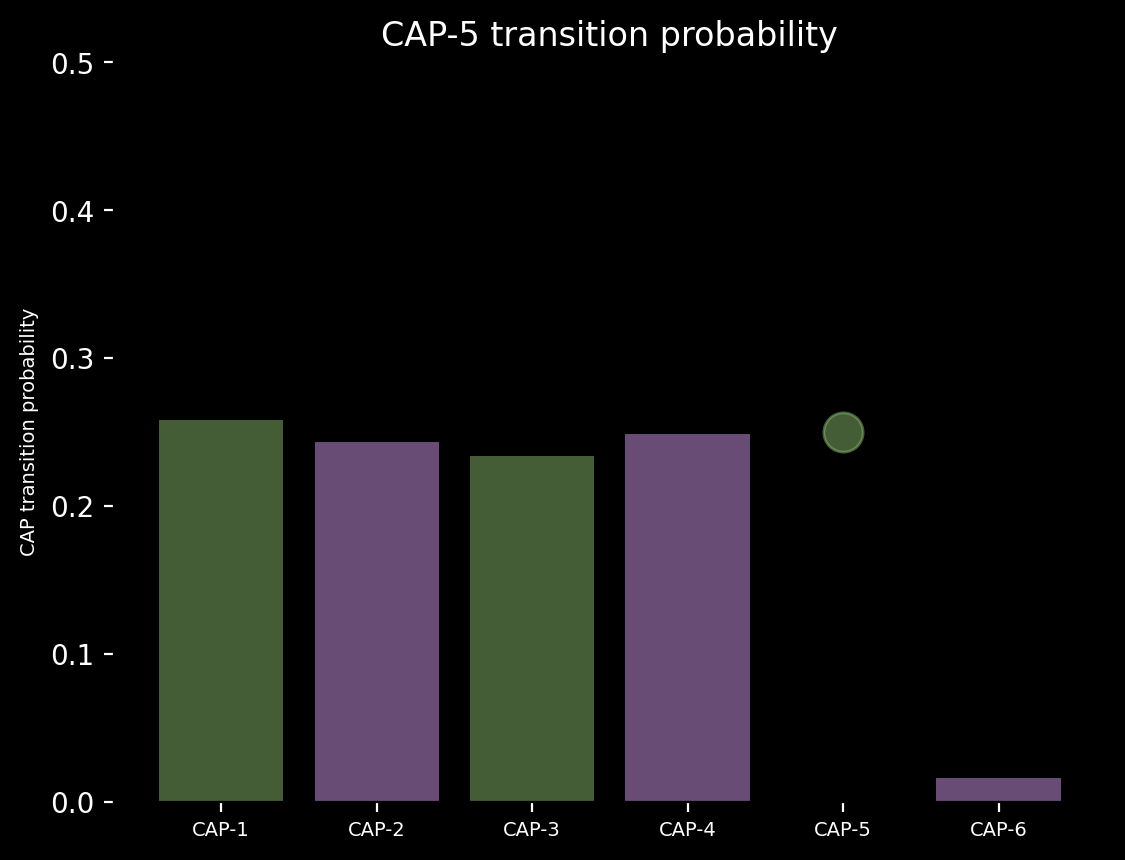

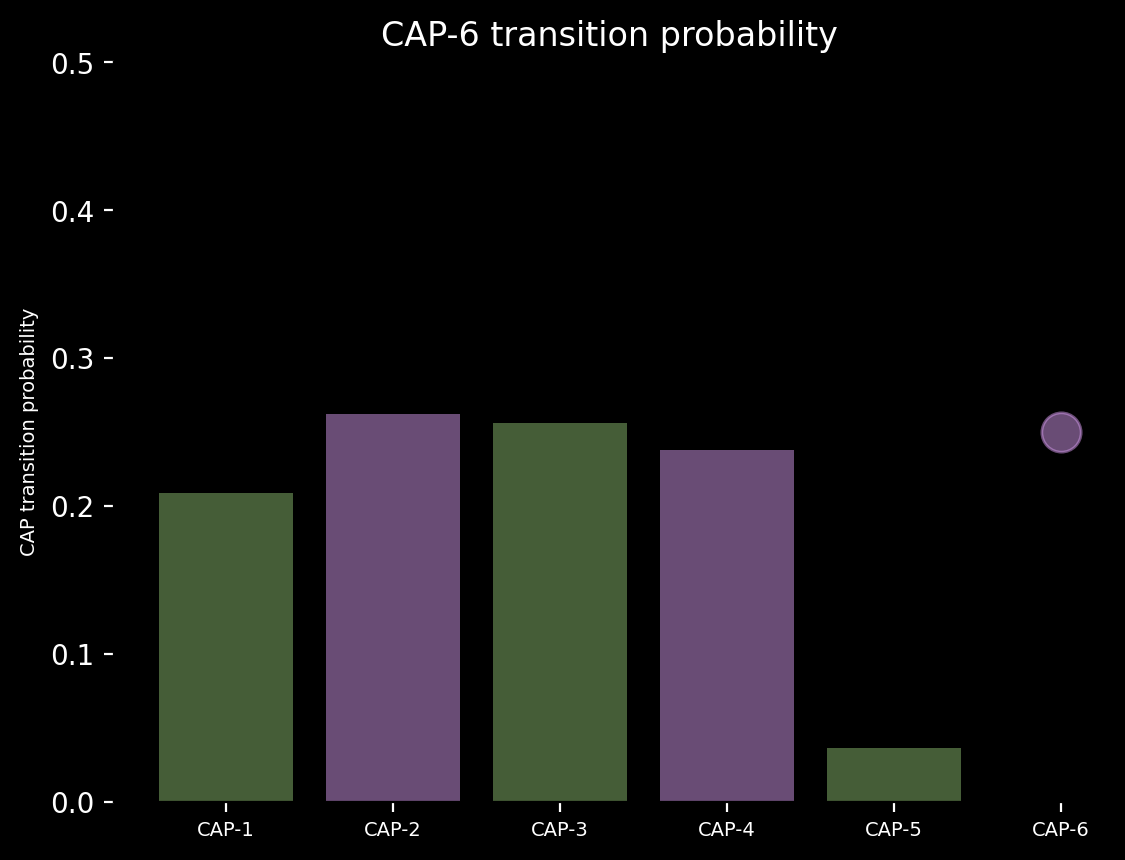

In [12]:
transition_matrices_norm = transition_matrices.copy()

for cohort_name in ds_name:
    
    for i,x in enumerate(transition_matrices[cohort_name]):
        
        fig, ax = plt.subplots(1,1 ,dpi = 200, facecolor = 'k')
        ax.set(facecolor = 'k')
        transitions = x/x.sum()
        display_cap_bar(transitions, ylim = 0.5, alpha = 0.5, cmap = cc.cm['CET_D2'])
        
        ax.set_yticks(np.arange(6)/10)
        ax.tick_params(colors = 'white')
        
        plt.title(f'CAP-{i+1} transition probability', c = 'w')
        
        save_name = save_dir / f'02_single-step_transition_distribution_cap-{i+1}.png'
        plt.savefig(save_name)
        save_name = save_dir / f'02_single-step_transition_distribution_cap-{i+1}.svg'
        plt.savefig(save_name)

## Second order

Computes the two step transition probability matrix.

### Parameters

In [13]:
save_dir = output_root / f'Sample-statistics/Second-order'
save_dir.mkdir(exist_ok = True, parents = True)

### Network of transitions

In [22]:
# remove self transitions

corrected_TS = [cohort_wise_indexes[ds_name[cohort_id]][0]]

for x in cohort_wise_indexes[ds_name[cohort_id]][1:]:

    if x!=corrected_TS[-1]:

        corrected_TS.append(x)

corrected_TS = np.array(corrected_TS)

# Computes transition stats

count_matrix = np.zeros((nb_caps, nb_caps, nb_caps))

for x,y,z in zip(corrected_TS[:-2].astype(int), corrected_TS[1:-1].astype(int), corrected_TS[2:].astype(int)):

    count_matrix[x-1,y-1,z-1] = count_matrix[x-1,y-1,z-1] + 1

transition_matrix = count_matrix.copy()

transition_matrix = transition_matrix/transition_matrix.sum()

transition_matrices[cohort_name] = transition_matrix

print(f'Total number of events: {count_matrix.sum().astype(int)}')

Total number of events: 7478


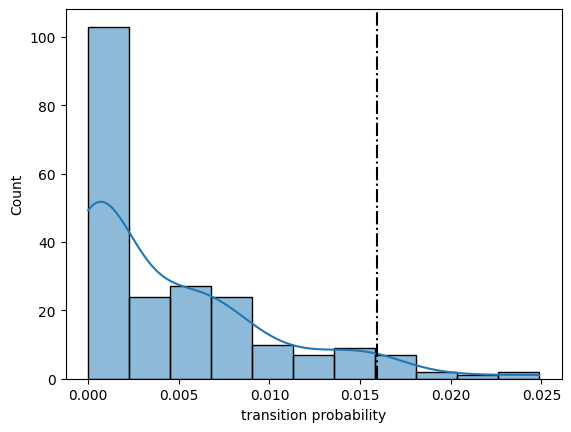

In [23]:
# checks of the probability distribution

df = pd.DataFrame({'transition probability':transition_matrices[cohort_name].flatten()})

sns.histplot(df, x = 'transition probability', kde = True)

plt.axvline(np.percentile(transition_matrices[cohort_name],95), ls = '-.', c = 'k')

In [24]:
cycle_dict = {'cycle':[cycle for cycle in np.argwhere(transition_matrices[cohort_name] > np.percentile(transition_matrices[cohort_name],95))+1]}

cycle_dict['probability'] = [transition_matrices[cohort_name][cycle[0]-1, cycle[1]-1, cycle[2]-1] for cycle in cycle_dict['cycle']]

cycle_df = pd.DataFrame(cycle_dict)

cycle_df.sort_values(by = ['probability'], ascending = False)[:6]


,cycle,probability
5,"[3, 1, 4]",0.024873
2,"[1, 4, 2]",0.024606
8,"[4, 2, 3]",0.021396
3,"[2, 3, 1]",0.020193
7,"[4, 1, 3]",0.018320
1,"[1, 3, 6]",0.017652


In [25]:
second_order_transitions = count_matrix.sum(1)
second_order_transitions = second_order_transitions/second_order_transitions.sum()

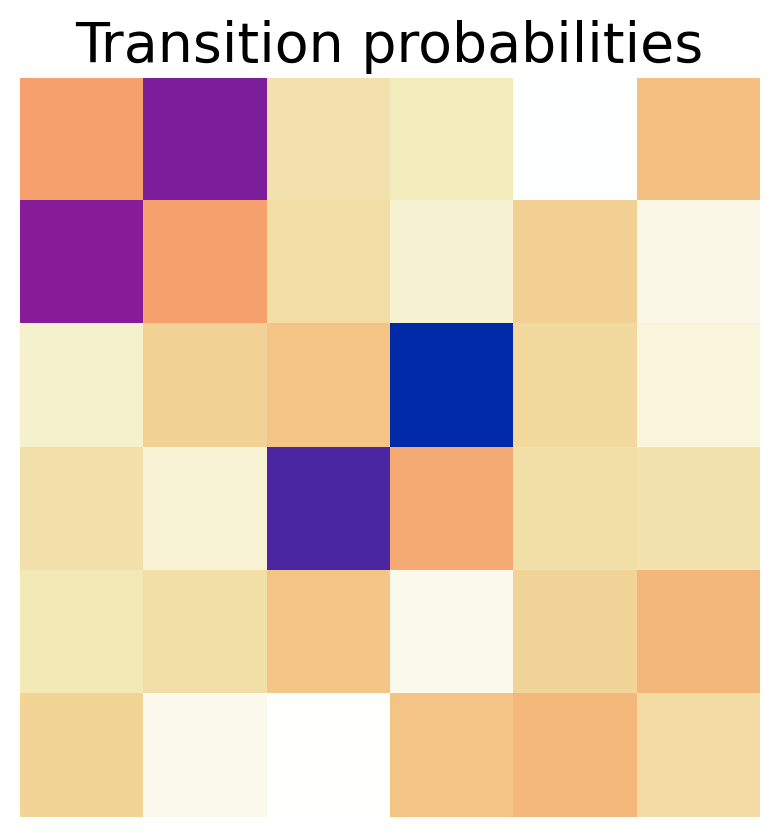

In [26]:
plt.figure(dpi = 200)

# plt.imshow(second_order_transitions, cmap = cc.cm['CET_CBL2'])
# plt.imshow(second_order_transitions, cmap = 'inferno')
plt.imshow(second_order_transitions, cmap = cc.cm['CET_L17'])
plt.axis('off')

plt.title('Transition probabilities', fontsize = 20)


save_name = save_dir / f'03_two-step_transition_matrix.png'
plt.savefig(save_name)
save_name = save_dir / f'03_two-step_transition_matrix.svg'
plt.savefig(save_name)

In [27]:
# Gets the display threshold based on control cohort

cohort_id = 0

maxs = []

for x, y in zip(second_order_transitions, second_order_transitions.T):
    
    maxs.append(min(max(x), max(y)))


# th = np.floor(maxs[np.argmin(maxs)]*1000)/1000
th = maxs[np.argmin(maxs)]
    
print(f'{np.argmin(maxs)} - {maxs[np.argmin(maxs)]} - th =  {th}')

4 - 0.02968708210751538 - th =  0.02968708210751538


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


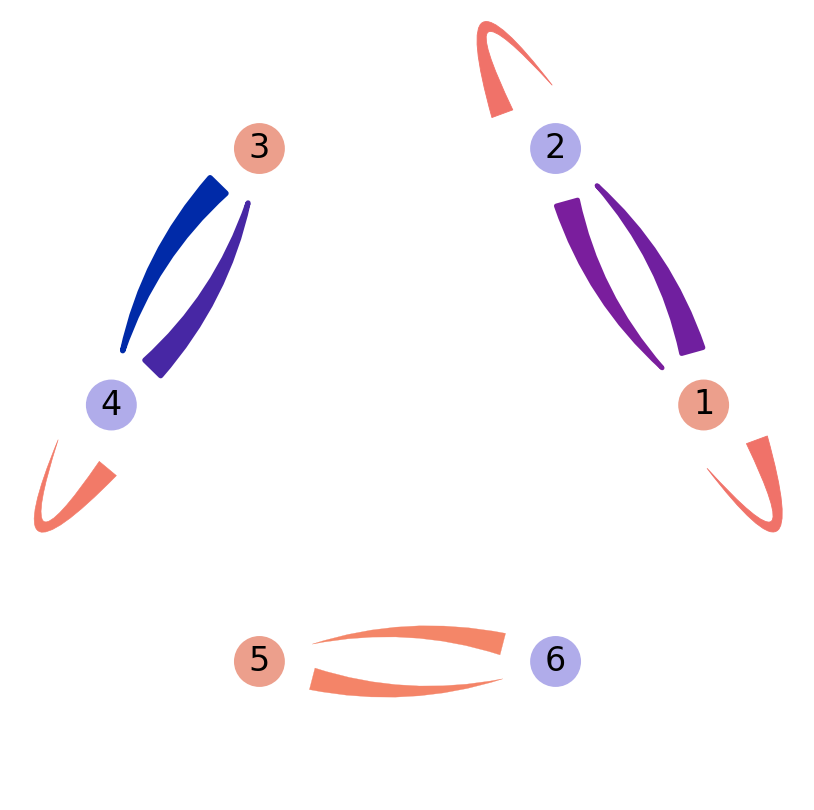

In [28]:
# displays networks

for cohort_name in ds_name:

    fig, ax = display_transition_matrix(second_order_transitions, edge_threshold = th, edge_width_factor = 50)
        
    plt.axis([-1.3, 1.3, -1.3, 1.3])
    
    save_name = save_dir / f'04_two-step_transition_network.png'
    plt.savefig(save_name)
    save_name = save_dir / f'04_two-step_transition_network.svg'
    plt.savefig(save_name)

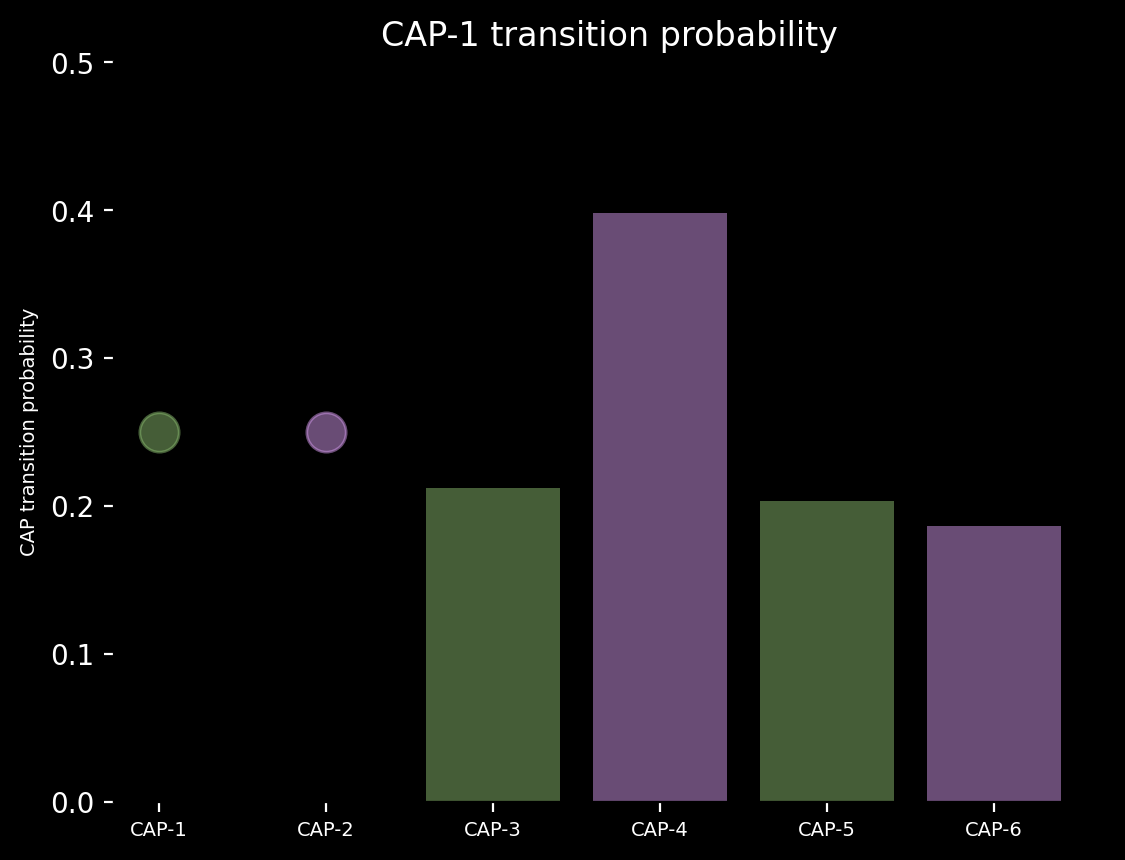

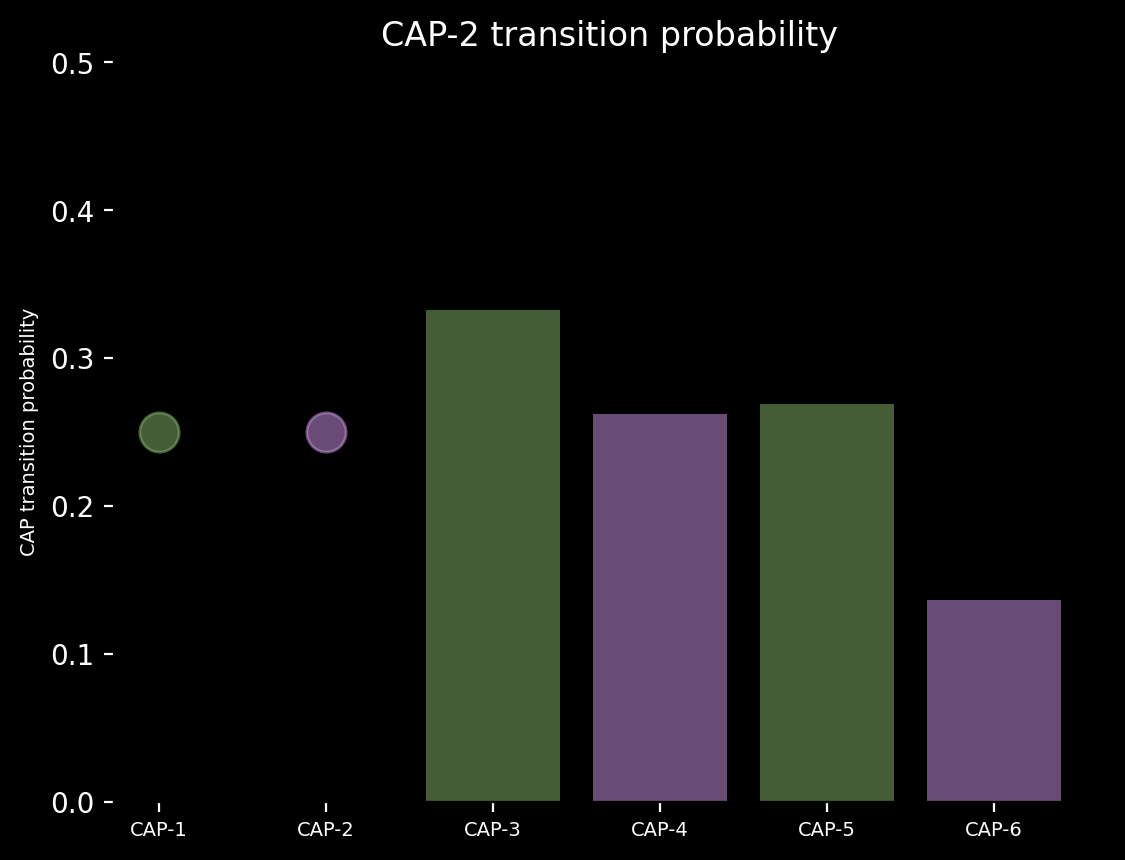

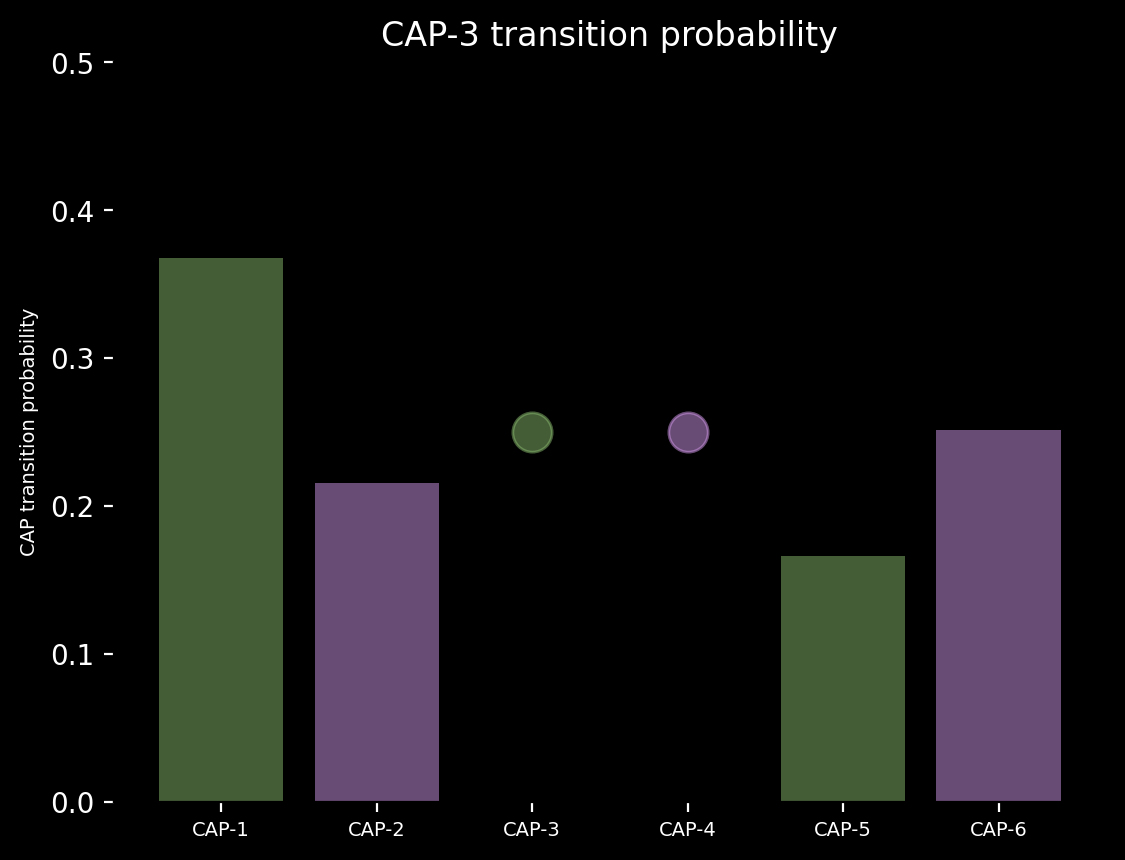

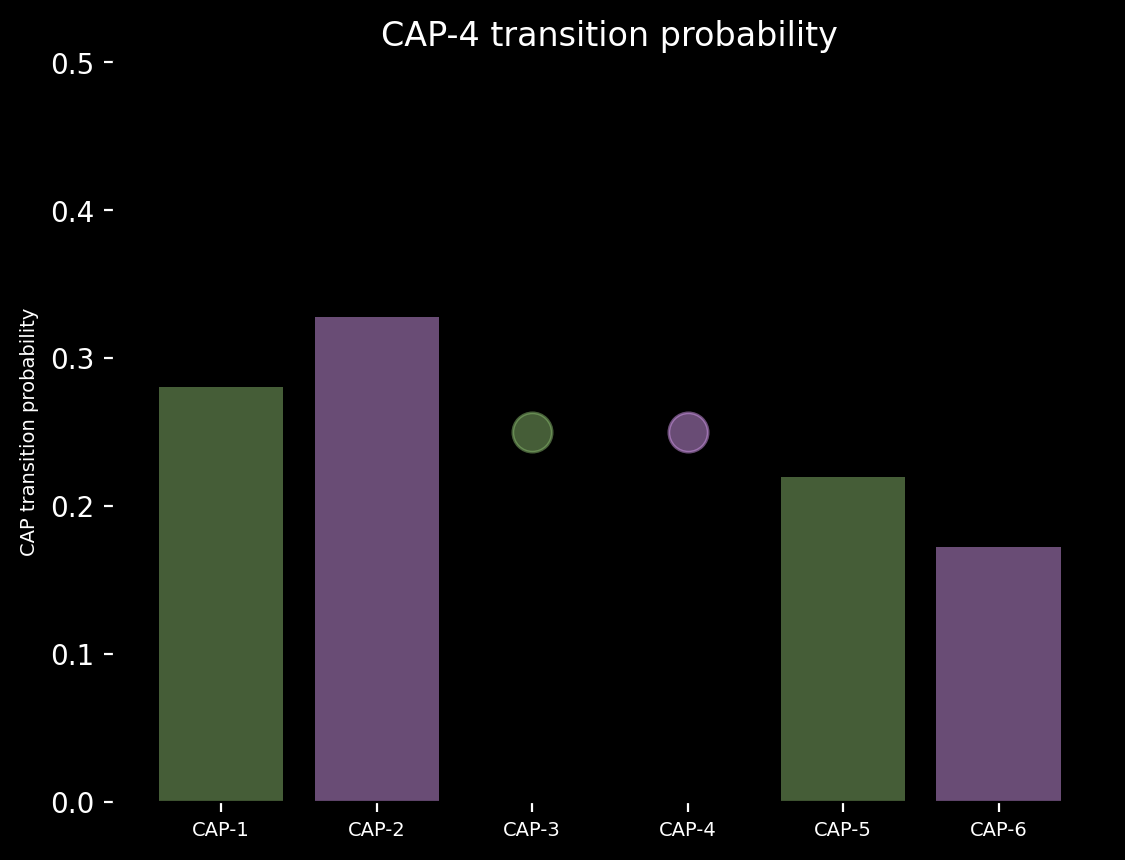

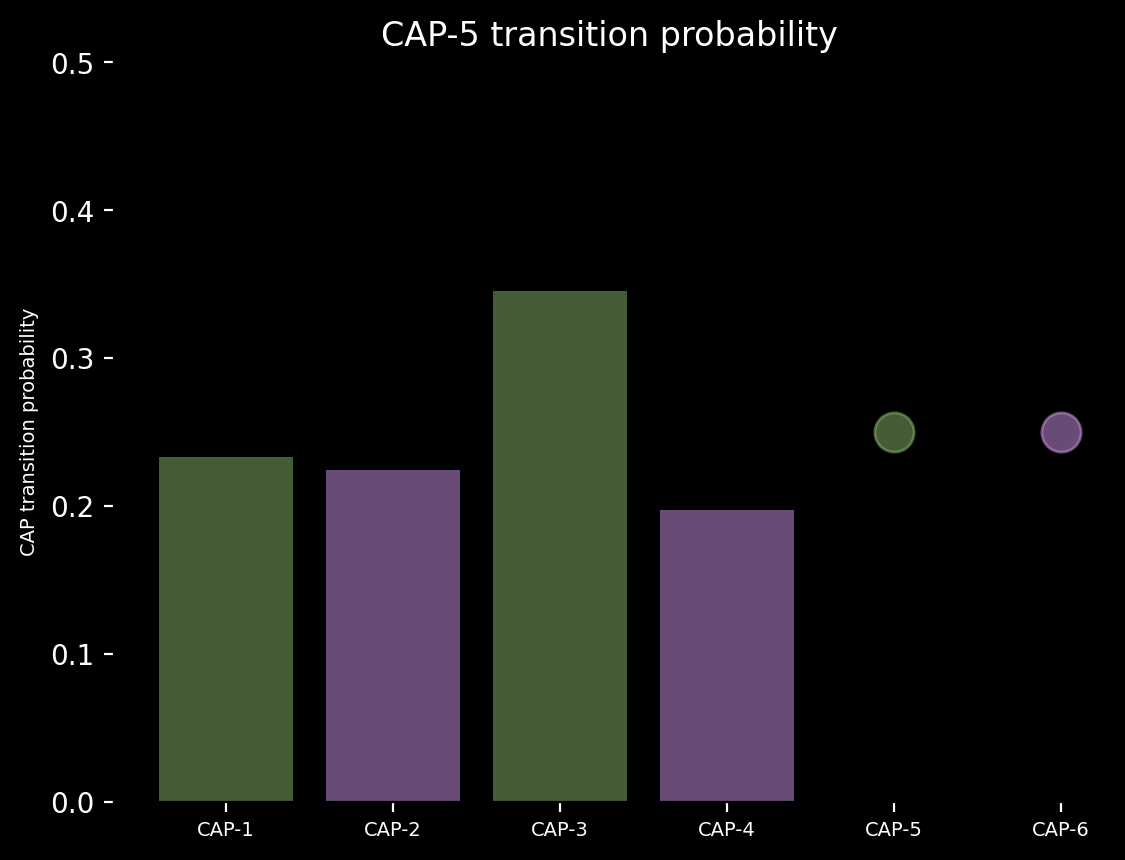

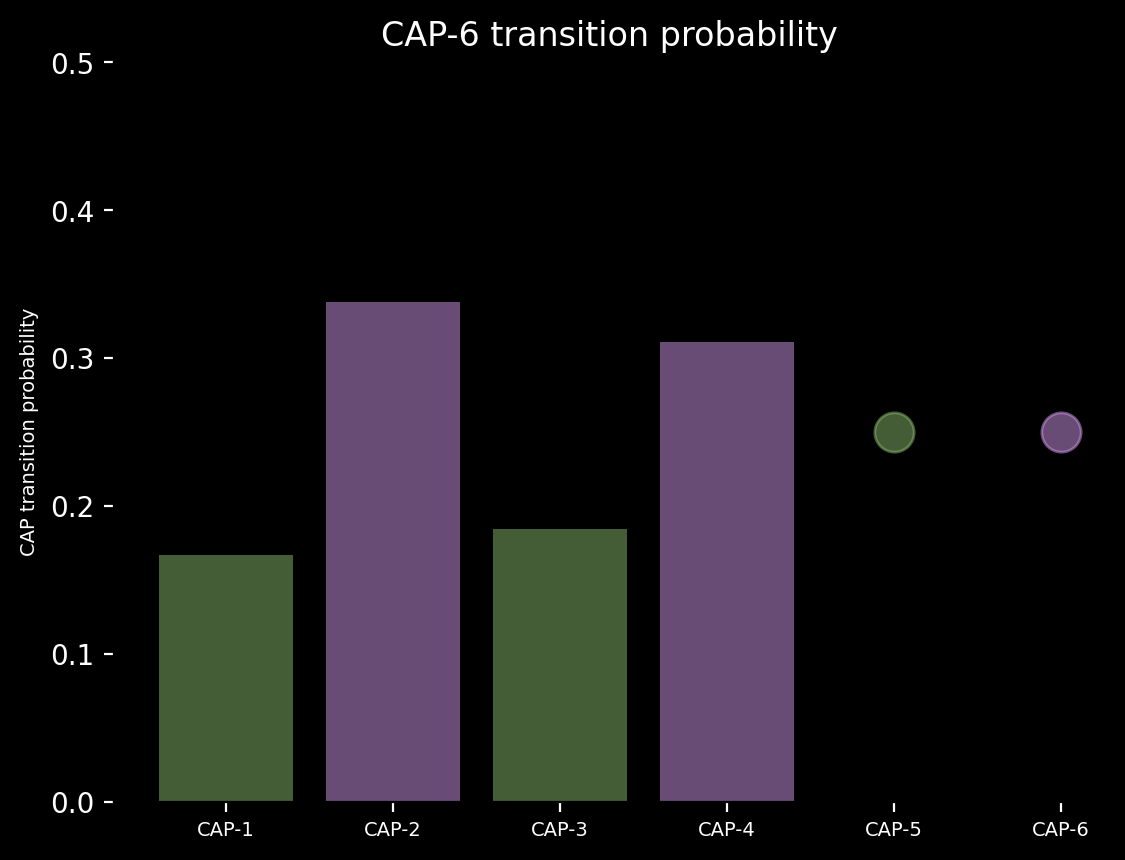

In [29]:
# display intermediary transition probability

sources_targets = [
    [1,2],
    [2,1],
    [3,4],
    [4,3],
    [5,6],
    [6,5]
]

for i,[source, target] in enumerate(sources_targets):

    x = count_matrix[source-1,:,target-1]
    
    fig, ax = plt.subplots(1,1 ,dpi = 200, facecolor = 'k')
    ax.set(facecolor = 'k')
    transitions = x/x.sum()
    display_cap_bar(transitions, ylim = 0.5, alpha = 0.5, cmap = cc.cm['CET_D2'])

    ax.set_yticks(np.arange(6)/10)
    ax.tick_params(colors = 'white')

    plt.title(f'CAP-{i+1} transition probability', c = 'w')
    
    save_name = save_dir / f'05_two-step_transition_distribution_cap-{i+1}.png'
    plt.savefig(save_name)
    save_name = save_dir / f'05_two-step_transition_distribution_cap-{i+1}.svg'
    plt.savefig(save_name)

# Population Statistics

Computes the subject level transition and performs statistics at the population level.

## Loads data

In [30]:
# Loads the data

sub_list_name = root_name / Path(f'subject_list_CPT.mat')

indexes = []

with h5py.File(cap_res_name, 'r') as f:
    
    for x in f['results_map']['frame_ind_sub'] :
        
        indexes.append(apply_new_order(f[x[0]][:][0,:], new_order))
        
# Getting indexes of cohorts subject

cohort_lens = []
cohort_starts = []
count = 0

with h5py.File(sub_list_name,'r') as f:

    for x in f['sub_list']:

        cohort_lens.append(f[x[0]].shape[1])
        cohort_starts.append(count)
        count = count + f[x[0]].shape[1]
        
cohort_starts.append(len(indexes))

cohort_wise_indexes = {}
subject_wise_indexes = {x:[] for x in ds_name}

for i,(start, end) in enumerate(zip(cohort_starts[:-1], cohort_starts[1:])):
    
    cohort_wise_indexes[ds_name[i]] = np.zeros((0))
    
    for j in range(start, end):
        
        cohort_wise_indexes[ds_name[i]] = np.concatenate(
            (cohort_wise_indexes[ds_name[i]], indexes[j]),
            0
        )
        
        subject_wise_indexes[ds_name[i]].append(indexes[j])

## First order

### Parameters

In [32]:
save_dir = output_root / f'Population-statistics/First-order'
save_dir.mkdir(exist_ok = True, parents = True)

### Network of transitions

In [33]:
# Computes the transition matrix subject wise

transition_matrices = []

for index in indexes:

    count_matrix = np.zeros((nb_caps, nb_caps))

    for x,y in zip(cohort_wise_indexes[ds_name[cohort_id]][:-1].astype(int), cohort_wise_indexes[ds_name[cohort_id]][1:].astype(int)):

        count_matrix[x-1,y-1] = count_matrix[x-1,y-1] + 1

    for i in range(nb_caps):
        count_matrix[i,i] = 0

    transition_matrix = count_matrix.copy()

    transition_matrix = transition_matrix/transition_matrix.sum()
    
    transition_matrices.append(transition_matrix)

# comptes population level estimate

avg_matrix = np.mean(transition_matrices,0)

Text(0.5, 1.0, 'Probability')

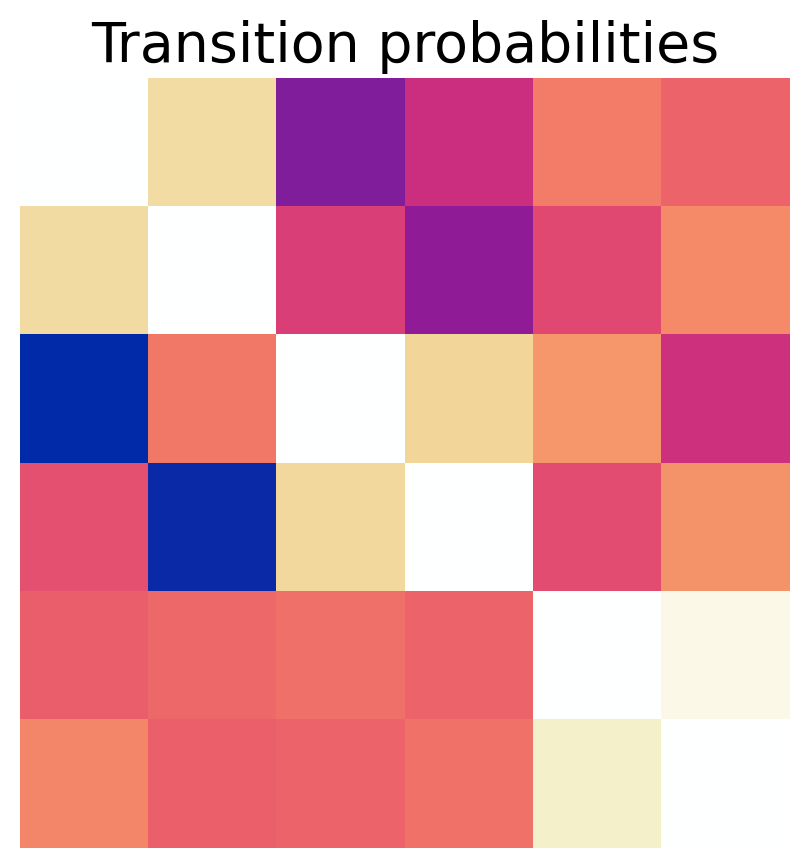

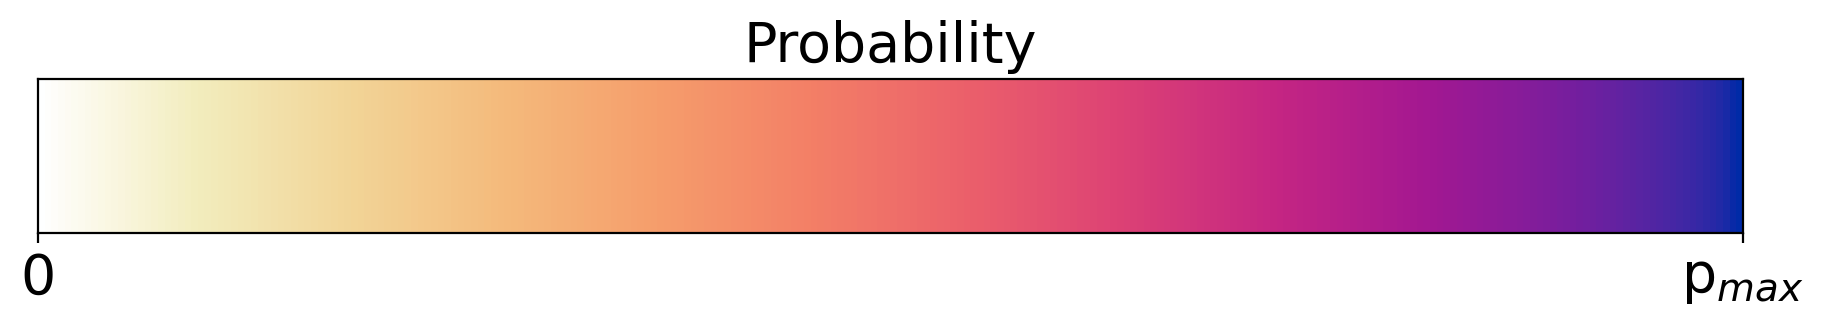

In [34]:
# displays transition probability matrix and associated colorbar

colormap_tag = 'CET_L17'

cmap = cc.cm[colormap_tag]

plt.figure(figsize = (5,5), dpi = 200)

plt.imshow(avg_matrix, cmap = cmap)
plt.axis('off')

plt.title('Transition probabilities', fontsize = 20)

v = np.linspace(0,1, 256)

save_name = save_dir / f'00_single-step_transition_matrix_{colormap_tag}.png'
save_name.parent.mkdir(exist_ok = True, parents = True)
plt.savefig(save_name)
save_name = save_dir / f'00_single-step_transition_matrix_{colormap_tag}.svg'
plt.savefig(save_name)

###################### Colorbar

plt.figure(figsize = (11, 1), dpi = 200)

plt.imshow(v[:,None].T, cmap = cmap, aspect = 'auto')

plt.xticks([-0.5,255.5], ['0', 'p$_{max}$'], fontsize = 20)
plt.yticks([])

plt.title('Probability', fontsize = 20)

# save_name = save_dir / f'00_single-step_transition_matrix_colorbar_{colormap_tag}.png'
# plt.savefig(save_name)
# save_name = save_dir / f'00_single-step_transition_matrix_colorbar_{colormap_tag}.svg'
# plt.savefig(save_name)

In [35]:
# Gets the display threshold based on control cohort

cohort_id = 0

maxs = []

for x, y in zip(avg_matrix, avg_matrix.T):
    
    maxs.append(min(max(x), max(y)))


# th = np.floor(maxs[np.argmin(maxs)]*1000)/1000
th = maxs[np.argmin(maxs)]
    
print(f'{np.argmin(maxs)} - {maxs[np.argmin(maxs)]} - th =  {th}')

5 - 0.03596737531755583 - th =  0.03596737531755583


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 1000x1000 with 0 Axes>

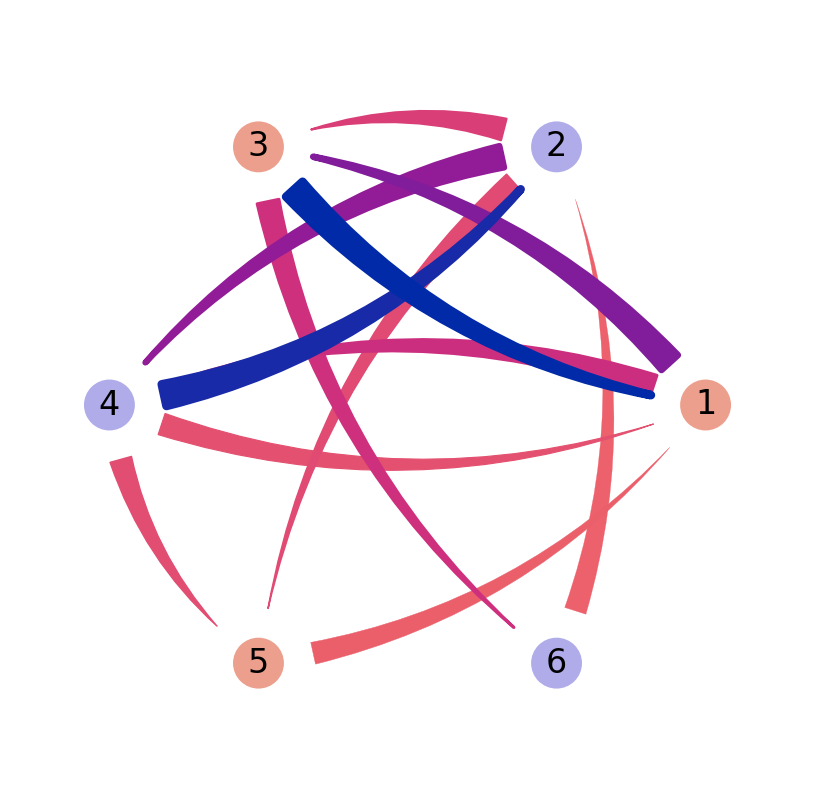

In [36]:
# displays networks

for cohort_name in ds_name:

    plt.figure(figsize = (5,5), dpi = 200)
    display_transition_matrix(avg_matrix, edge_threshold = th, edge_width_factor = 100, cmap_net = cmap)
    
    plt.axis([-1.3, 1.3, -1.3, 1.3])

## Second order

### Parameters

In [37]:
save_dir = output_root / f'Sample-statistics/Second-order'
save_dir.mkdir(exist_ok = True, parents = True)

### Network of transitions

In [38]:
# Computes the second order transition matrix subject wise

transition_matrices = []

for index in indexes:
    
    # remove self transitions
    
    corrected_TS = [index[0]]
    
    for x in index[1:]:
    
        if x!=corrected_TS[-1]:
    
            corrected_TS.append(x)
    
    corrected_TS = np.array(corrected_TS)
    
    # Computes transition stats
    
    count_matrix = np.zeros((nb_caps, nb_caps, nb_caps))
    
    for x,y,z in zip(corrected_TS[:-2].astype(int), corrected_TS[1:-1].astype(int), corrected_TS[2:].astype(int)):
    
        count_matrix[x-1,y-1,z-1] = count_matrix[x-1,y-1,z-1] + 1
    
    transition_matrix = count_matrix.copy().sum(1)
    
    transition_matrix = transition_matrix/transition_matrix.sum()

    transition_matrices.append(transition_matrix)
    
    print(count_matrix.sum())

# computes the population level estimate

avg_matrix = np.median(transition_matrices,0)

554.0
588.0
619.0
587.0
566.0
579.0
556.0
570.0
562.0
561.0
554.0
600.0
558.0


Text(0.5, 1.0, 'Probability')

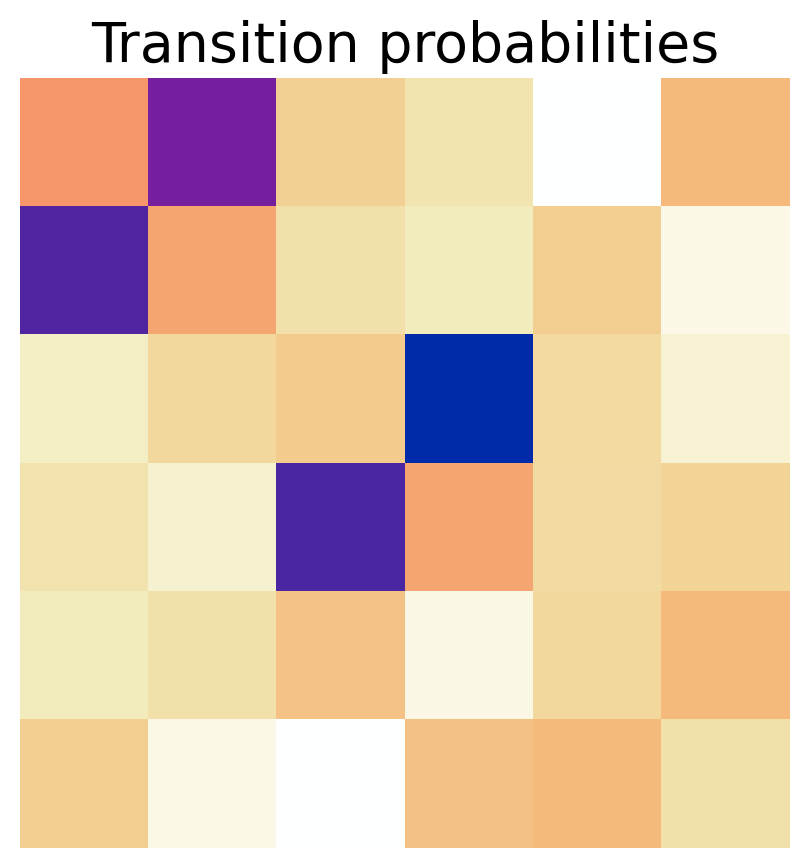

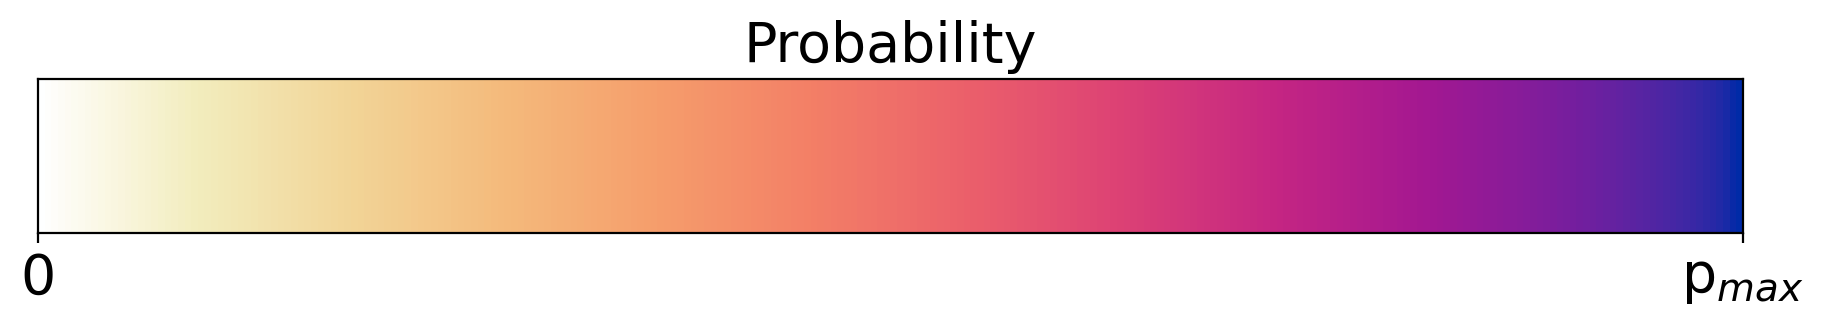

In [39]:
# displays transition probability matrix and associated colorbar

colormap_tag = 'CET_L17'

# alternative cmap strategies

cmap = cc.cm[colormap_tag]

plt.figure(figsize = (5,5), dpi = 200)

plt.imshow(avg_matrix, cmap = cmap)
plt.axis('off')

plt.title('Transition probabilities', fontsize = 20)

v = np.linspace(0,1, 256)

save_name = save_dir / f'00_single-step_transition_matrix_{colormap_tag}.png'
save_name.parent.mkdir(exist_ok = True, parents = True)
plt.savefig(save_name)
save_name = save_dir / f'00_single-step_transition_matrix_{colormap_tag}.svg'
plt.savefig(save_name)

###################### Colorbar

plt.figure(figsize = (11, 1), dpi = 200)

plt.imshow(v[:,None].T, cmap = cmap, aspect = 'auto')

plt.xticks([-0.5,255.5], ['0', 'p$_{max}$'], fontsize = 20)
plt.yticks([])

plt.title('Probability', fontsize = 20)


In [40]:
# Gets the display threshold based on control cohort

cohort_id = 0

maxs = []

for x, y in zip(avg_matrix, avg_matrix.T):
    
    maxs.append(min(max(x), max(y)))


# th = np.floor(maxs[np.argmin(maxs)]*1000)/1000
th = maxs[np.argmin(maxs)]
    
print(f'{np.argmin(maxs)} - {maxs[np.argmin(maxs)]} - th =  {th}')

4 - 0.02867383512544803 - th =  0.02867383512544803


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 1000x1000 with 0 Axes>

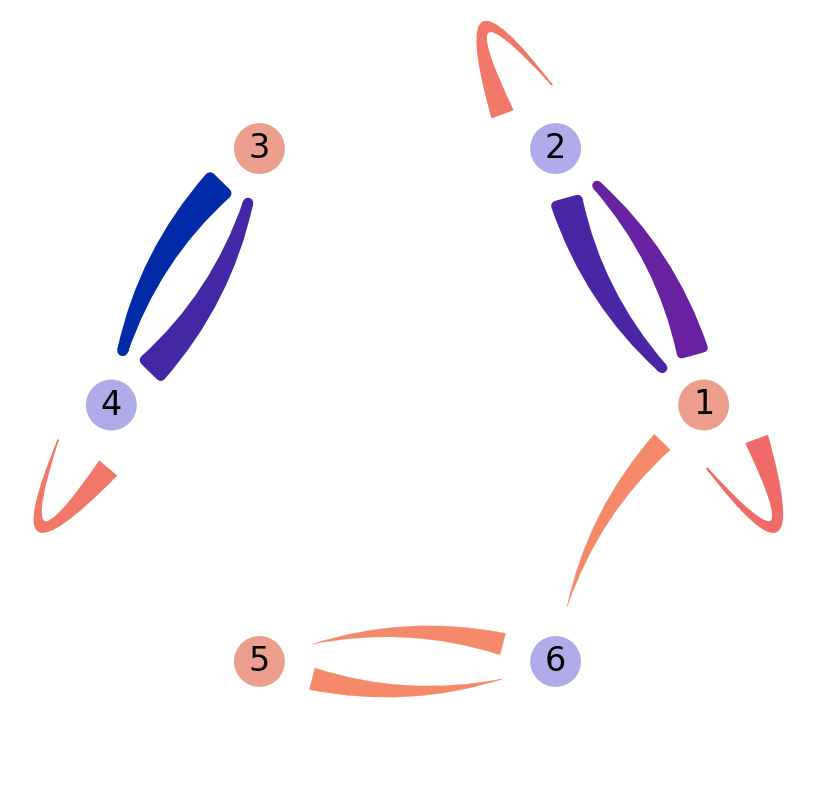

In [41]:
# displays networks

for cohort_name in ds_name:

    plt.figure(figsize = (5,5), dpi = 200)
    display_transition_matrix(avg_matrix, edge_threshold = th, edge_width_factor = 100, cmap_net = cmap)
    
    plt.axis([-1.3, 1.3, -1.3, 1.3])